In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [81]:
df = pd.read_csv("../data/raw/diabetes_prediction_dataset.csv")
display(df.head())
display(df.info())
display(df.nunique())
display(df.isnull().sum())
display(df[df.isnull().any(axis=1)])
display(df.duplicated().value_counts())

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


None

gender                    3
age                     102
hypertension              2
heart_disease             2
smoking_history           6
bmi                    4247
HbA1c_level              18
blood_glucose_level      18
diabetes                  2
dtype: int64

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes


False    96146
True      3854
Name: count, dtype: int64

In [82]:
df = df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96146 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               96146 non-null  object 
 1   age                  96146 non-null  float64
 2   hypertension         96146 non-null  int64  
 3   heart_disease        96146 non-null  int64  
 4   smoking_history      96146 non-null  object 
 5   bmi                  96146 non-null  float64
 6   HbA1c_level          96146 non-null  float64
 7   blood_glucose_level  96146 non-null  int64  
 8   diabetes             96146 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 7.3+ MB


In [83]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000
mean,41.794326,0.077601,0.040803,27.321461,5.532609,138.218231,0.088220
std,22.462948,0.267544,0.197833,6.767716,1.073232,40.909771,0.283616
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.400000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,59.000000,0.000000,0.000000,29.860000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


In [84]:
df['diabetes'].value_counts()

diabetes
0    87664
1     8482
Name: count, dtype: int64

In [85]:
df['diabetes'].value_counts(normalize=True)

diabetes
0    0.91178
1    0.08822
Name: proportion, dtype: float64

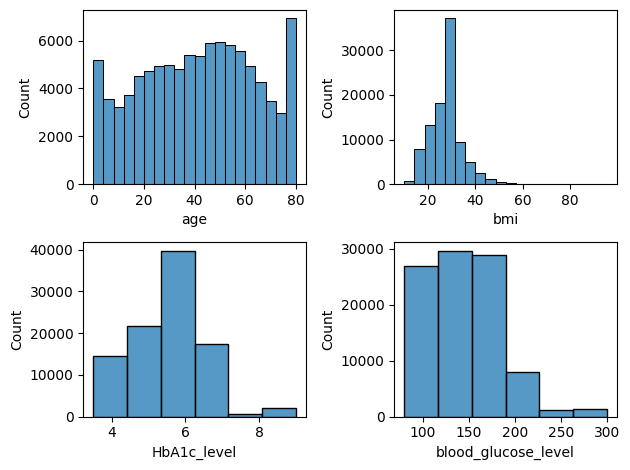

In [86]:
figure,ax = plt.subplots(2,2)

sns.histplot(df['age'],bins=20,ax=ax[0,0])

sns.histplot(df['bmi'],bins=20,ax=ax[0,1])

sns.histplot(df['HbA1c_level'],bins=6,ax=ax[1,0])

sns.histplot(df['blood_glucose_level'],bins=6,ax=ax[1,1])

plt.tight_layout()

plt.show()

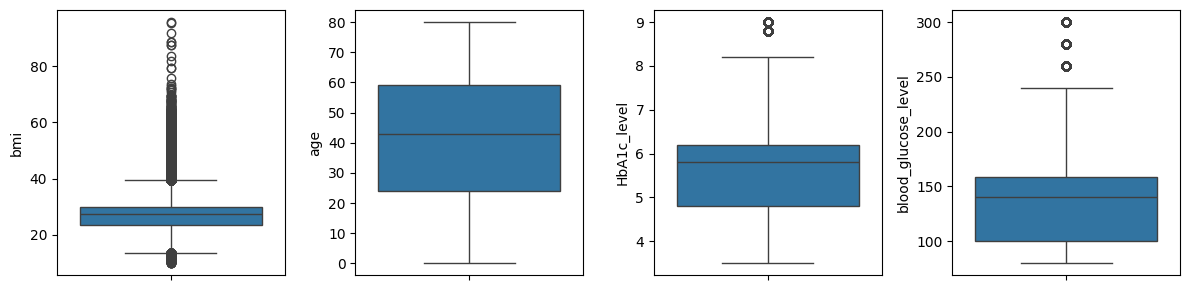

In [87]:
figure,ax = plt.subplots(1,4,figsize=(12,3))

sns.boxplot(df['bmi'],ax=ax[0])
sns.boxplot(df['age'],ax=ax[1])
sns.boxplot(df['HbA1c_level'],ax=ax[2])
sns.boxplot(df['blood_glucose_level'],ax=ax[3])

plt.tight_layout()
plt.show()

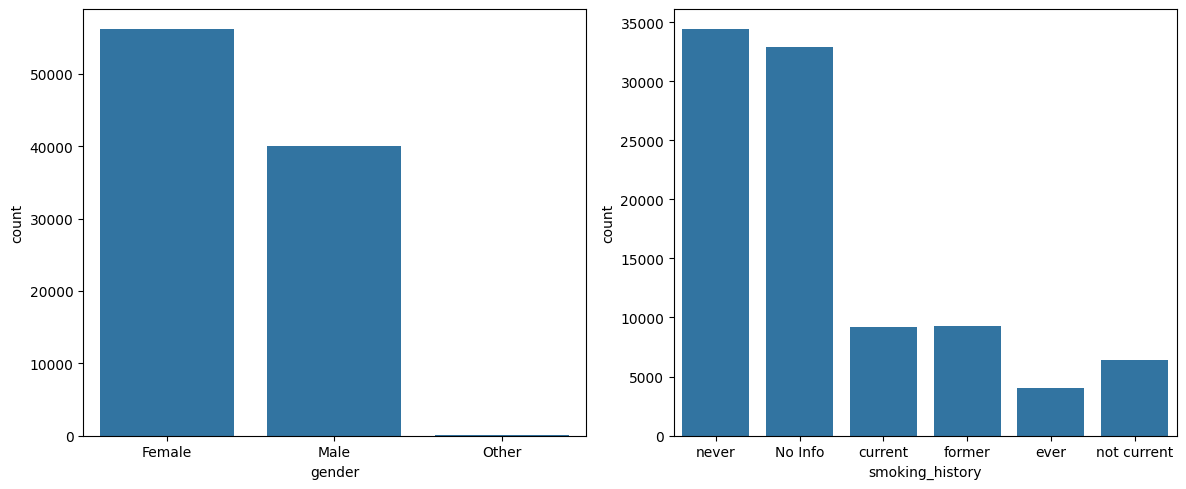

In [88]:
figure,ax = plt.subplots(1,2,figsize=(12,5))

sns.countplot(
    data=df,
    x='gender',
    ax=ax[0]
)
sns.countplot(
    data=df,
    x='smoking_history',
    ax=ax[1]
)


plt.tight_layout()
plt.show()

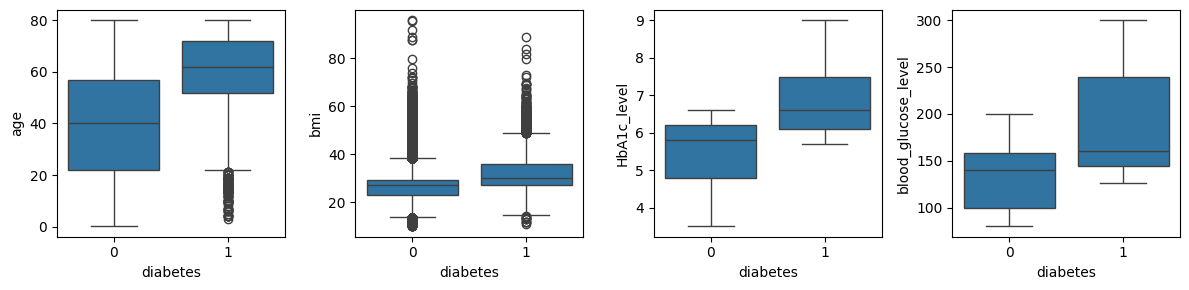

In [89]:
figure,ax = plt.subplots(1,4,figsize=(12,3))

sns.boxplot(
    data=df,
    x='diabetes',
    y='age',
    ax=ax[0]
)

sns.boxplot(
    data=df,
    x='diabetes',
    y='bmi',
    ax=ax[1]
)

sns.boxplot(
    data=df,
    x='diabetes',
    y='HbA1c_level',
    ax=ax[2]
)

sns.boxplot(
    data=df,
    x='diabetes',
    y='blood_glucose_level',
    ax=ax[3]
)

plt.tight_layout()
plt.show()

In [90]:
dxgendr = pd.crosstab(
    df['gender'],
    df['diabetes'],
    normalize='index'
)
dxsmoking = pd.crosstab(
    df['smoking_history'],
    df['diabetes'],
    normalize='index'
)
display(dxgendr,dxsmoking)


diabetes,0,1
gender,,
Female,0.920817,0.079183
Male,0.899042,0.100958
Other,1.000000,0.000000


diabetes,0,1
smoking_history,,
No Info,0.956062,0.043938
current,0.896923,0.103077
ever,0.881941,0.118059
former,0.829014,0.170986
never,0.902989,0.097011
not current,0.891629,0.108371


<Axes: >

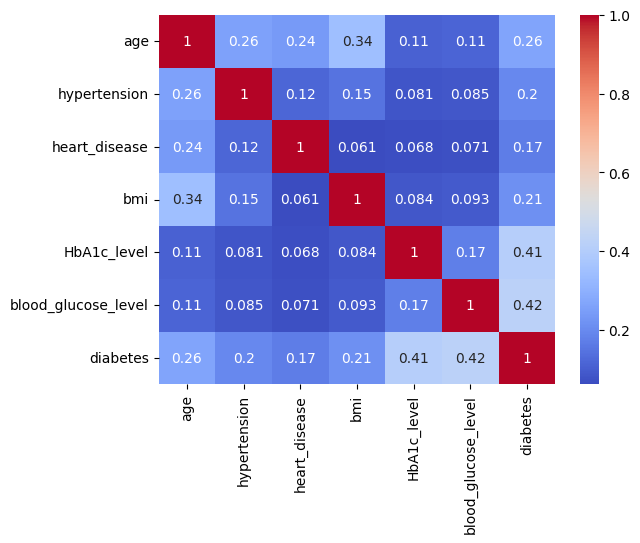

In [91]:
corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

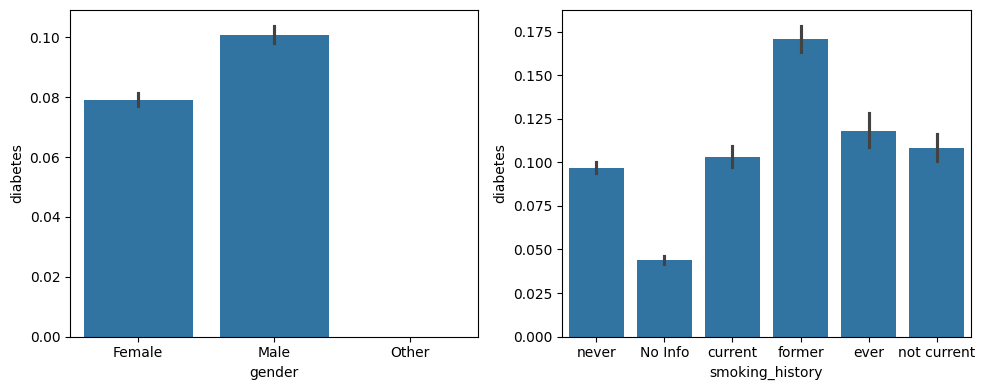

In [92]:
figure,ax = plt.subplots(1,2,figsize=(10,4))

sns.barplot(data=df, x='gender', y='diabetes', ax=ax[0])

sns.barplot(data=df, x='smoking_history', y='diabetes',ax=ax[1])

plt.tight_layout()
plt.show()

<Axes: >

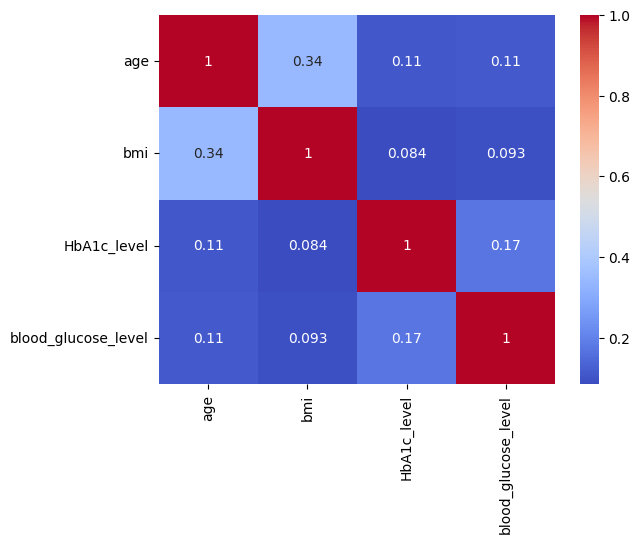

In [93]:
num_cols = [
    'age',
    'bmi',
    'HbA1c_level',
    'blood_glucose_level'
]

df[num_cols].corr()

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

In [94]:
df.groupby('smoking_history')['age'].mean()

smoking_history
No Info        32.629883
current        44.102803
ever           49.146823
former         57.020432
never          43.877373
not current    47.687910
Name: age, dtype: float64

In [95]:
df['gender'].value_counts()

gender
Female    56161
Male      39967
Other        18
Name: count, dtype: int64